# E-Commerce Sales & Delivery Performance Analysis
### Olist Brazilian E-Commerce Dataset

**Business question:** What's driving late deliveries and low review scores, and which product categories/regions should the business prioritize fixing first?

**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) | ~100k orders, 2016–2018.

**Approach:** SQL (via DuckDB, run directly over the raw CSVs) for extraction/joins, pandas for cleaning and analysis, matplotlib/seaborn/plotly for visualization.

---


## 1. Setup

In [1]:
# If duckdb isn't preinstalled in this Kaggle environment, uncomment:
# !pip install duckdb -q

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    for f in files[:5]:  # just first 5 files per folder to avoid a huge dump
        print("   ", f)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/organizations
/kaggle/input/datasets/organizations/olistbr
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce
    olist_customers_dataset.csv
    olist_sellers_dataset.csv
    olist_order_reviews_dataset.csv
    olist_order_items_dataset.csv
    olist_products_dataset.csv


In [3]:
# Path to the dataset once attached to this Kaggle Notebook
# (Kaggle mounts attached datasets under /kaggle/input/<dataset-slug>/)
DATA_DIR = "/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce"
import os
print(os.listdir(DATA_DIR))


['olist_customers_dataset.csv', 'olist_sellers_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_order_items_dataset.csv', 'olist_products_dataset.csv', 'olist_geolocation_dataset.csv', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_order_payments_dataset.csv']


## 2. Load Data

DuckDB can query CSV files directly with SQL | no import/load step needed. `con.execute(...).df()` runs a SQL query and returns a pandas DataFrame.

In [4]:
con = duckdb.connect()

orders = con.execute(f"""
    SELECT * FROM read_csv_auto('{DATA_DIR}/olist_orders_dataset.csv')
""").df()

order_items = con.execute(f"""
    SELECT * FROM read_csv_auto('{DATA_DIR}/olist_order_items_dataset.csv')
""").df()

products = con.execute(f"""
    SELECT * FROM read_csv_auto('{DATA_DIR}/olist_products_dataset.csv')
""").df()

customers = con.execute(f"""
    SELECT * FROM read_csv_auto('{DATA_DIR}/olist_customers_dataset.csv')
""").df()

sellers = con.execute(f"""
    SELECT * FROM read_csv_auto('{DATA_DIR}/olist_sellers_dataset.csv')
""").df()

reviews = con.execute(f"""
    SELECT * FROM read_csv_auto('{DATA_DIR}/olist_order_reviews_dataset.csv')
""").df()

payments = con.execute(f"""
    SELECT * FROM read_csv_auto('{DATA_DIR}/olist_order_payments_dataset.csv')
""").df()

category_translation = con.execute(f"""
    SELECT * FROM read_csv_auto('{DATA_DIR}/product_category_name_translation.csv')
""").df()

print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("products:", products.shape)
print("customers:", customers.shape)
print("sellers:", sellers.shape)
print("reviews:", reviews.shape)
print("payments:", payments.shape)


orders: (99441, 8)
order_items: (112650, 7)
products: (32951, 9)
customers: (99441, 5)
sellers: (3095, 4)
reviews: (99224, 7)
payments: (103886, 5)


## 3. Explore Before Analyzing

Row counts, date ranges, nulls, and how tables relate | do this before writing any "real" analysis query. Skipping this step is the most common cause of wrong conclusions later.

In [5]:
orders.info()
orders.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), object(3)
memory usage: 6.1+ MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [6]:
# Order status breakdown | which statuses exist, and how many are usable for delivery analysis?
orders["order_status"].value_counts()


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [7]:
# Date range covered
print(orders["order_purchase_timestamp"].min(), "to", orders["order_purchase_timestamp"].max())


2016-09-04 21:15:19 to 2018-10-17 17:30:18


In [8]:
# Null check on the columns we'll need most (delivery dates, review scores)
orders[["order_delivered_customer_date", "order_estimated_delivery_date"]].isna().sum()


order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

## 4. Clean Data

- Keep only `delivered` orders for delivery-time analysis (cancelled/unavailable orders have no delivery date).
- Convert date columns to datetime.
- Drop duplicate reviews if any (one review can technically appear more than once per order in raw exports).

In [9]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

delivered = orders[orders["order_status"] == "delivered"].copy()
print(f"{len(delivered)} of {len(orders)} orders are 'delivered' and usable for delivery-time analysis")


96478 of 99441 orders are 'delivered' and usable for delivery-time analysis


In [10]:
reviews = reviews.drop_duplicates(subset="review_id")


In [11]:
# Merge product category (Portuguese -> English) into products
products = products.merge(category_translation, on="product_category_name", how="left")
products["product_category_name_english"] = products["product_category_name_english"].fillna("unknown")


## 5. Q1 | Which categories drive revenue vs. order volume? (Pareto analysis)

In [12]:
revenue_by_category = con.execute("""
    SELECT
        p.product_category_name_english AS category,
        COUNT(DISTINCT oi.order_id)     AS n_orders,
        SUM(oi.price)                   AS total_revenue
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    GROUP BY 1
    ORDER BY total_revenue DESC
""").df()

revenue_by_category["revenue_share"] = revenue_by_category["total_revenue"] / revenue_by_category["total_revenue"].sum()
revenue_by_category["cum_revenue_share"] = revenue_by_category["revenue_share"].cumsum()
revenue_by_category.head(15)


,category,n_orders,total_revenue,revenue_share,cum_revenue_share
0,health_beauty,8836,1258681.34,0.092607,0.092607
1,watches_gifts,5624,1205005.68,0.088658,0.181265
2,bed_bath_table,9417,1036988.68,0.076296,0.257561
3,sports_leisure,7720,988048.97,0.072695,0.330256
4,computers_accessories,6689,911954.32,0.067097,0.397353
5,furniture_decor,6449,729762.49,0.053692,0.451045
6,cool_stuff,3632,635290.85,0.046741,0.497786
7,housewares,5884,632248.66,0.046517,0.544304
8,auto,3897,592720.11,0.043609,0.587913
9,garden_tools,3518,485256.46,0.035703,0.623615


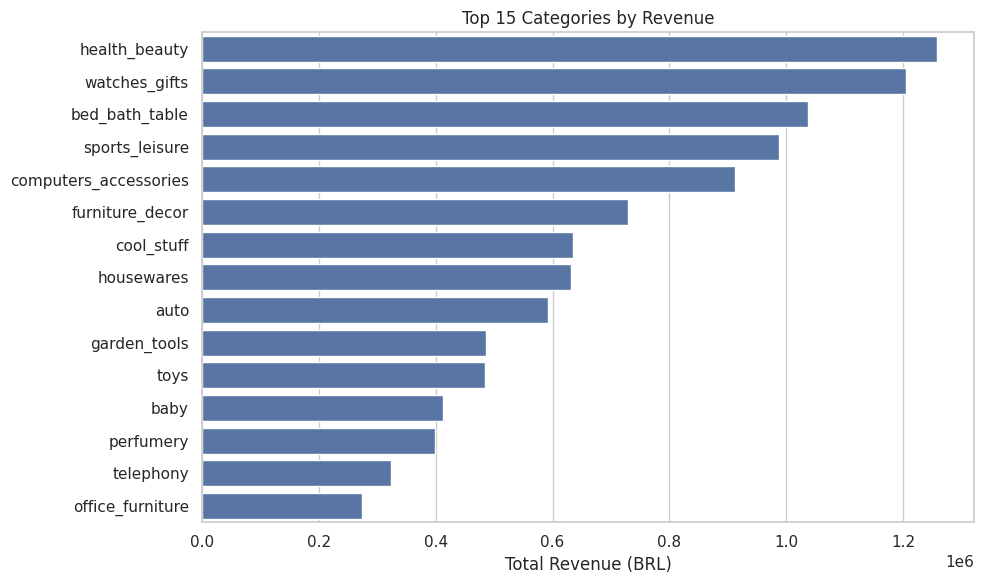

17 of 72 categories account for ~80% of revenue


In [13]:
top15 = revenue_by_category.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top15, y="category", x="total_revenue", ax=ax, color="#4C72B0")
ax.set_title("Top 15 Categories by Revenue")
ax.set_xlabel("Total Revenue (BRL)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

n_categories_for_80pct = (revenue_by_category["cum_revenue_share"] <= 0.8).sum()
print(f"{n_categories_for_80pct} of {len(revenue_by_category)} categories account for ~80% of revenue")


## 6. Q2 | Delivery Delay vs. Review Score

Delay = actual delivery date − estimated delivery date. Positive = late. This is the centerpiece analysis | worth a proper statistical check, not just a chart.

In [14]:
delivered = delivered.merge(
    reviews[["order_id", "review_score"]], on="order_id", how="left"
)

delivered["delivery_delay_days"] = (
    delivered["order_delivered_customer_date"] - delivered["order_estimated_delivery_date"]
).dt.days

delay_review = delivered.dropna(subset=["delivery_delay_days", "review_score"])
delay_review[["delivery_delay_days", "review_score"]].describe()


,delivery_delay_days,review_score
count,95601.000000,95601.000000
mean,-11.909802,4.157781
std,10.108066,1.283187
min,-147.000000,1.000000
25%,-17.000000,4.000000
50%,-12.000000,5.000000
75%,-7.000000,5.000000
max,188.000000,5.000000


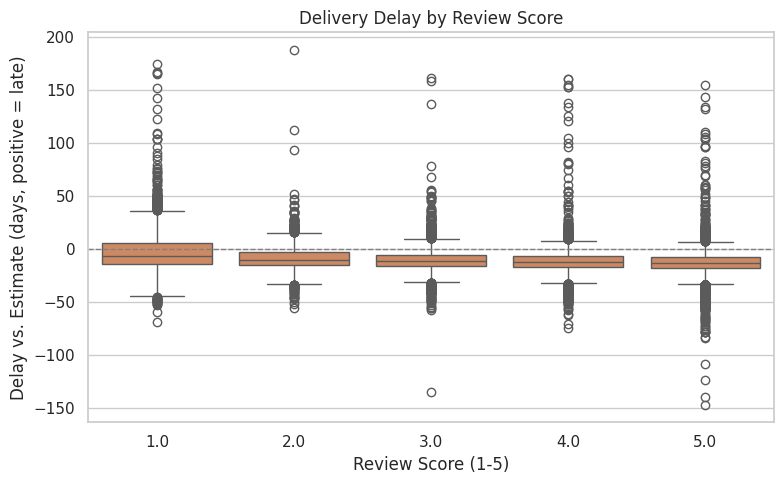

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=delay_review,
    x="review_score",
    y="delivery_delay_days",
    ax=ax,
    color="#DD8452",
)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Delivery Delay by Review Score")
ax.set_xlabel("Review Score (1-5)")
ax.set_ylabel("Delay vs. Estimate (days, positive = late)")
plt.tight_layout()
plt.show()


In [16]:
from scipy import stats

corr, p_value = stats.pearsonr(delay_review["delivery_delay_days"], delay_review["review_score"])
print(f"Pearson correlation: {corr:.3f}  (p = {p_value:.2e})")

# Simple bucketed comparison: on-time/early vs. >7 days late
on_time = delay_review[delay_review["delivery_delay_days"] <= 0]["review_score"]
very_late = delay_review[delay_review["delivery_delay_days"] > 7]["review_score"]

print(f"On-time/early orders  -> avg review score: {on_time.mean():.2f}  (n={len(on_time)})")
print(f"7+ days late orders   -> avg review score: {very_late.mean():.2f}  (n={len(very_late)})")

t_stat, t_p = stats.ttest_ind(on_time, very_late, equal_var=False)
print(f"t-test p-value: {t_p:.2e}")


Pearson correlation: -0.268  (p = 0.00e+00)
On-time/early orders  -> avg review score: 4.29  (n=89240)
7+ days late orders   -> avg review score: 1.69  (n=2772)
t-test p-value: 0.00e+00


## 7. Q3 | Regional Delivery Performance

Do specific Brazilian states consistently get slower delivery?

In [17]:
delivered_geo = delivered.merge(
    customers[["customer_id", "customer_state"]], on="customer_id", how="left"
)

state_delay = (
    delivered_geo.dropna(subset=["delivery_delay_days"])
    .groupby("customer_state")
    .agg(
        avg_delay_days=("delivery_delay_days", "mean"),
        n_orders=("order_id", "nunique"),
    )
    .sort_values("avg_delay_days", ascending=False)
)
state_delay


,avg_delay_days,n_orders
customer_state,,
AL,-8.692500,397
MA,-9.616134,717
SE,-10.020896,335
ES,-10.499250,1995
BA,-10.795524,3256
CE,-10.817187,1279
MS,-11.035562,701
SP,-11.078454,40494
PI,-11.297694,476


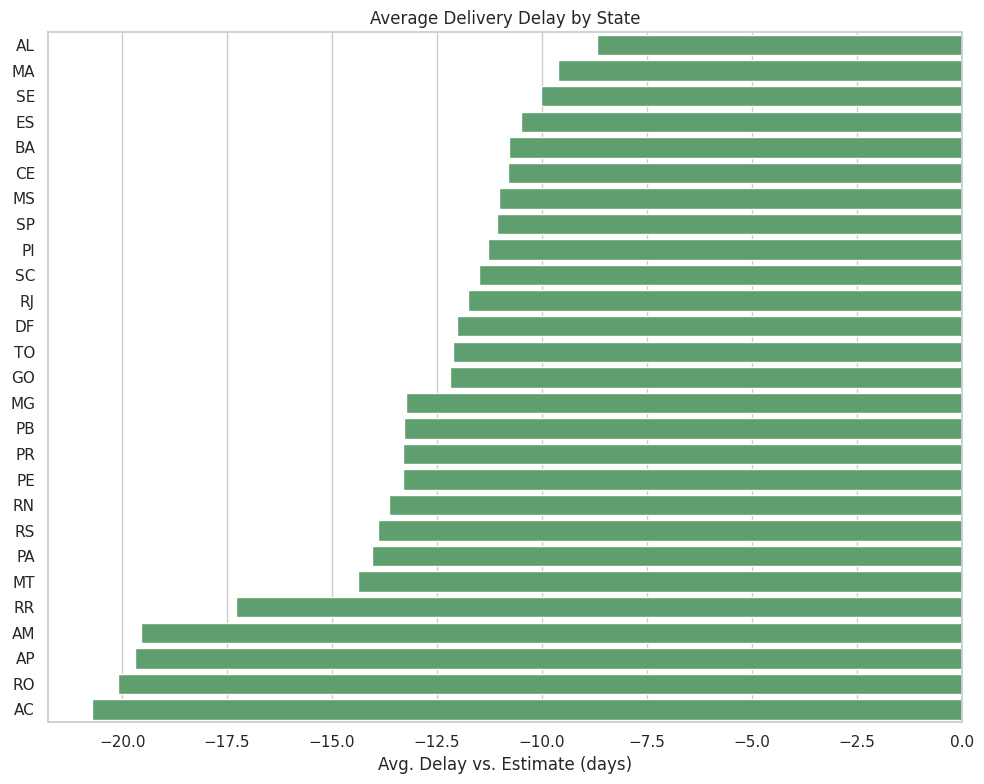

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=state_delay.reset_index(),
    y="customer_state",
    x="avg_delay_days",
    ax=ax,
    color="#55A868",
)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Average Delivery Delay by State")
ax.set_xlabel("Avg. Delay vs. Estimate (days)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 8. Q4 | Seasonality

Monthly order volume trend | useful for planning inventory/staffing.

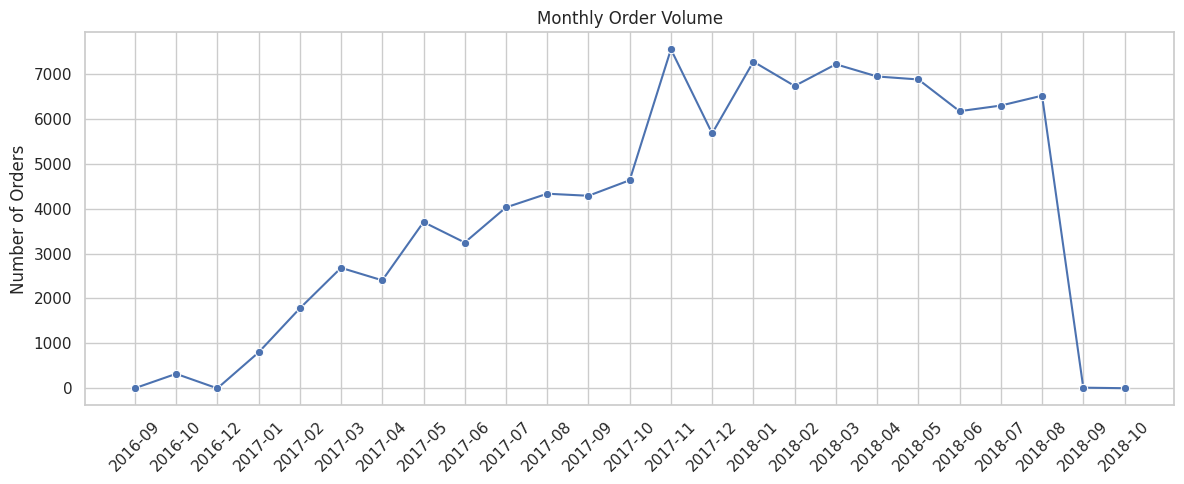

In [19]:
monthly_orders = (
    orders.dropna(subset=["order_purchase_timestamp"])
    .assign(month=lambda d: d["order_purchase_timestamp"].dt.to_period("M").astype(str))
    .groupby("month")
    .size()
    .reset_index(name="n_orders")
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=monthly_orders, x="month", y="n_orders", marker="o", ax=ax)
ax.set_title("Monthly Order Volume")
ax.set_xlabel("")
ax.set_ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 9. Q5 | Payment Type vs. Order Value

Do installment payments differ meaningfully from single payments?

In [20]:
payment_summary = (
    payments.groupby("payment_type")
    .agg(
        n_orders=("order_id", "nunique"),
        avg_value=("payment_value", "mean"),
        avg_installments=("payment_installments", "mean"),
    )
    .sort_values("n_orders", ascending=False)
)
payment_summary


,n_orders,avg_value,avg_installments
payment_type,,,
credit_card,76505,163.319021,3.507155
boleto,19784,145.034435,1.000000
voucher,3866,65.703354,1.000000
debit_card,1528,142.570170,1.000000
not_defined,3,0.000000,1.000000


## 10. Further Questions (not fully explored here)

These are worth naming in the write-up as scoped-out / future work rather than answering all of them in this first pass:

- Seller performance: do high-volume sellers maintain review scores as well as low-volume sellers?
- Freight cost as % of order value vs. review score / cancellation | a hidden churn driver separate from delivery speed?
- Repeat purchase rate by category.
- Product weight/dimensions vs. delivery delay.
- Review-score variance by category (inconsistent quality vs. mismatched expectations).


## 11. Key Findings Summary

**Finding 1 — Revenue concentration:** Revenue is concentrated in a relatively small number of product categories. The top 17 of 72 categories account for approximately 80% of total product revenue, with health & beauty (9.3%), watches & gifts (8.9%), and bed & bath table (7.6%) contributing the largest individual shares. **Recommendation:** Prioritize inventory availability, seller performance, and operational monitoring for high-revenue categories first, since disruptions in these categories have a larger potential impact on overall sales.

**Finding 2 — Delivery delays are strongly associated with lower reviews:** Delivery performance is strongly associated with customer satisfaction. The Pearson correlation between delivery delay and review score is **-0.268 (p < 0.001)**. Orders delivered on time or early received an average review score of **4.29**, compared with only **1.69** among orders delivered more than 7 days late. **Recommendation:** Treat delivery reliability as a priority CX issue, with particular attention to orders at risk of significant delays and earlier intervention when estimated delivery dates are likely to be missed.

**Finding 3 — Regional delivery performance varies substantially:** Average delivery performance differs considerably across Brazilian states. Among states with at least 50 orders, average delivery delay ranges from approximately **-8.7 days in Alagoas (AL)** to **-20.7 days in Acre (AC)**, although states with smaller order volumes should be interpreted cautiously. **Recommendation:** Investigate the logistics and fulfillment conditions of regions with weaker delivery performance rather than applying a single nationwide intervention.

**Recommendation:** Prioritize delivery reliability in high-revenue categories and investigate regional logistics differences to identify where operational improvements can produce the greatest customer-experience impact.

**Limitations:** The analysis identifies associations rather than causation. The delay–review relationship may also be influenced by factors not examined here, such as product category, seller performance, order characteristics, and customer expectations. Regional averages should also be interpreted cautiously for states with smaller sample sizes; the analysis uses a minimum of 50 orders for regional comparison.


## 12. Export for Streamlit App

Save the cleaned/aggregated tables needed by the dashboard so the Streamlit app doesn't have to redo the full pipeline.

In [21]:
revenue_by_category.to_csv("revenue_by_category.csv", index=False)
delay_review.to_csv("delay_review.csv", index=False)
state_delay.reset_index().to_csv("state_delay.csv", index=False)
monthly_orders.to_csv("monthly_orders.csv", index=False)
payment_summary.reset_index().to_csv("payment_summary.csv", index=False)

print("Exported CSVs for the Streamlit app.")


Exported CSVs for the Streamlit app.


In [22]:
import os
print(os.listdir("/kaggle/working"))

['revenue_by_category.csv', 'state_delay.csv', 'payment_summary.csv', 'delay_review.csv', 'monthly_orders.csv', '.virtual_documents']
